In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 9.4 MB/s eta 0:00:00
   

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

In [ ]:
# ============================================================================
# CONFIGURATION & SETUP --
# ============================================================================

API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS = 2048
MAX_PER_CLASS = 5000

SEED = 15
EPOCHS_FINAL = 10
BATCH_SIZE = 16

# Set seed for reproducibility
def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")
print(f"Data Source: All materials from Materials Project (not limited to perovskites)")
print(f"Data Split Ratio - Training:Validation:Testing = 70:10:20")
print(f"Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print(f"Oversampling Method: SMOTE (Standard)")
print(f"Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%")

Seed set to 15
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Data Source: All materials from Materials Project (not limited to perovskites)
Data Split Ratio - Training:Validation:Testing = 70:10:20
Epochs: 10 (NO Early Stopping)
Oversampling Method: SMOTE (Standard)
Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%


In [ ]:
# ============================================================================
# DATA LOADING FROM MATERIALS PROJECT (ALL MATERIALS)
# ============================================================================

def load_materials_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """
    Load materials from Materials Project (ALL materials, not just perovskites)
    Filter by target crystal systems only
    """

    data_records = []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        print("Querying Materials Project for all materials...")
        print(f"Target crystal systems: {TARGET_SYSTEMS}")
        print(f"Maximum samples per class: {max_per_class}")
        print()

        # Query materials by crystal system (one by one to control the number)
        for crystal_system in TARGET_SYSTEMS:
            print(f"\nFetching {crystal_system} materials...")

            # Search for materials with specific crystal system
            # Using pagination to get more results
            docs = mpr.materials.summary.search(
                crystal_system=crystal_system,
                fields=["material_id", "structure", "symmetry", "formula_pretty",
                       "density", "volume", "nsites"],
                num_chunks=10,  # Get more results
                chunk_size=1000  # Larger chunks
            )

            print(f"Found {len(docs)} {crystal_system} materials")

            # Process each material
            for doc in docs:
                # Check if we have enough for this class
                if class_counts[crystal_system] >= max_per_class:
                    break

                # Verify crystal system
                sym = getattr(doc, "symmetry", None)
                if sym is None or sym.crystal_system is None:
                    continue

                cs_raw = sym.crystal_system
                if hasattr(cs_raw, "value"):
                    cs = str(cs_raw.value).lower()
                else:
                    cs_str = str(cs_raw)
                    if "." in cs_str:
                        cs_str = cs_str.split(".")[-1]
                    cs = cs_str.lower()

                # Double check crystal system
                if cs != crystal_system:
                    continue

                structure = doc.structure
                if structure is None:
                    continue

                # Collect data
                record = {
                    'material_id': str(doc.material_id),
                    'formula': str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                    'crystal_system': cs,
                    'density': float(doc.density) if hasattr(doc, 'density') else None,
                    'volume': float(doc.volume) if hasattr(doc, 'volume') else None,
                    'nsites': int(doc.nsites) if hasattr(doc, 'nsites') else None,
                    'structure': structure
                }

                data_records.append(record)
                class_counts[cs] += 1

                # Progress update
                if class_counts[cs] % 100 == 0:
                    print(f"  {crystal_system}: {class_counts[cs]} samples collected...")

            print(f"✓ Completed {crystal_system}: {class_counts[cs]} samples")

    print("\n" + "="*70)
    print("DATA COLLECTION SUMMARY")
    print("="*70)
    print(f"Total materials collected: {len(data_records)}")
    print(f"\nClass distribution:")
    for system, count in class_counts.items():
        print(f"  {system.capitalize():<15}: {count:>6} samples")
    print("="*70)

    return pd.DataFrame(data_records)

# Load data
print("\n" + "="*70)
print("LOADING DATA FROM MATERIALS PROJECT")
print("="*70)
print("Source: ALL MATERIALS (not limited to perovskites)")
print("Filter: 4 crystal systems (cubic, monoclinic, orthorhombic, tetragonal)")
print("="*70)
df_materials = load_materials_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")


LOADING DATA FROM MATERIALS PROJECT
Source: ALL MATERIALS (not limited to perovskites)
Filter: 4 crystal systems (cubic, monoclinic, orthorhombic, tetragonal)
Querying Materials Project for all materials...
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Maximum samples per class: 5000


Fetching cubic materials...


Retrieving SummaryDoc documents:   0%|          | 0/10000 [00:00<?, ?it/s]

Found 10000 cubic materials
  cubic: 100 samples collected...
  cubic: 200 samples collected...
  cubic: 300 samples collected...
  cubic: 400 samples collected...
  cubic: 500 samples collected...
  cubic: 600 samples collected...
  cubic: 700 samples collected...
  cubic: 800 samples collected...
  cubic: 900 samples collected...
  cubic: 1000 samples collected...
  cubic: 1100 samples collected...
  cubic: 1200 samples collected...
  cubic: 1300 samples collected...
  cubic: 1400 samples collected...
  cubic: 1500 samples collected...
  cubic: 1600 samples collected...
  cubic: 1700 samples collected...
  cubic: 1800 samples collected...
  cubic: 1900 samples collected...
  cubic: 2000 samples collected...
  cubic: 2100 samples collected...
  cubic: 2200 samples collected...
  cubic: 2300 samples collected...
  cubic: 2400 samples collected...
  cubic: 2500 samples collected...
  cubic: 2600 samples collected...
  cubic: 2700 samples collected...
  cubic: 2800 samples collected...
 

Retrieving SummaryDoc documents:   0%|          | 0/10000 [00:00<?, ?it/s]

Found 10000 monoclinic materials
  monoclinic: 100 samples collected...
  monoclinic: 200 samples collected...
  monoclinic: 300 samples collected...
  monoclinic: 400 samples collected...
  monoclinic: 500 samples collected...
  monoclinic: 600 samples collected...
  monoclinic: 700 samples collected...
  monoclinic: 800 samples collected...
  monoclinic: 900 samples collected...
  monoclinic: 1000 samples collected...
  monoclinic: 1100 samples collected...
  monoclinic: 1200 samples collected...
  monoclinic: 1300 samples collected...
  monoclinic: 1400 samples collected...
  monoclinic: 1500 samples collected...
  monoclinic: 1600 samples collected...
  monoclinic: 1700 samples collected...
  monoclinic: 1800 samples collected...
  monoclinic: 1900 samples collected...
  monoclinic: 2000 samples collected...
  monoclinic: 2100 samples collected...
  monoclinic: 2200 samples collected...
  monoclinic: 2300 samples collected...
  monoclinic: 2400 samples collected...
  monoclinic: 25

Retrieving SummaryDoc documents:   0%|          | 0/10000 [00:00<?, ?it/s]

Found 10000 orthorhombic materials
  orthorhombic: 100 samples collected...
  orthorhombic: 200 samples collected...
  orthorhombic: 300 samples collected...
  orthorhombic: 400 samples collected...
  orthorhombic: 500 samples collected...
  orthorhombic: 600 samples collected...
  orthorhombic: 700 samples collected...
  orthorhombic: 800 samples collected...
  orthorhombic: 900 samples collected...
  orthorhombic: 1000 samples collected...
  orthorhombic: 1100 samples collected...
  orthorhombic: 1200 samples collected...
  orthorhombic: 1300 samples collected...
  orthorhombic: 1400 samples collected...
  orthorhombic: 1500 samples collected...
  orthorhombic: 1600 samples collected...
  orthorhombic: 1700 samples collected...
  orthorhombic: 1800 samples collected...
  orthorhombic: 1900 samples collected...
  orthorhombic: 2000 samples collected...
  orthorhombic: 2100 samples collected...
  orthorhombic: 2200 samples collected...
  orthorhombic: 2300 samples collected...
  orthor

Retrieving SummaryDoc documents:   0%|          | 0/10000 [00:00<?, ?it/s]

Found 10000 tetragonal materials
  tetragonal: 100 samples collected...
  tetragonal: 200 samples collected...
  tetragonal: 300 samples collected...
  tetragonal: 400 samples collected...
  tetragonal: 500 samples collected...
  tetragonal: 600 samples collected...
  tetragonal: 700 samples collected...
  tetragonal: 800 samples collected...
  tetragonal: 900 samples collected...
  tetragonal: 1000 samples collected...
  tetragonal: 1100 samples collected...
  tetragonal: 1200 samples collected...
  tetragonal: 1300 samples collected...
  tetragonal: 1400 samples collected...
  tetragonal: 1500 samples collected...
  tetragonal: 1600 samples collected...
  tetragonal: 1700 samples collected...
  tetragonal: 1800 samples collected...
  tetragonal: 1900 samples collected...
  tetragonal: 2000 samples collected...
  tetragonal: 2100 samples collected...
  tetragonal: 2200 samples collected...
  tetragonal: 2300 samples collected...
  tetragonal: 2400 samples collected...
  tetragonal: 25

In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================

# Check data types
print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)
print()

# Display columns/features
print("="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")
print()

# Display top 4 samples (excluding structure column for readability)
print("="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())


DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id  formula crystal_system    density      volume  nsites
0    mp-10018       Ac          cubic   8.157868   46.205987       1
1   mp-861724  Ac2AgIr          cubic  11.367264  110.157369       4
2  mp-1183076  Ac2AgPb          cubic   9.490476  134.563097       4
3  mp-1183068  Ac2CdGa          cubic   8.243210  128.144911       4


In [ ]:
# ============================================================================
# MISSING VALUES ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_data = df_materials.isnull().sum()
missing_percent = (df_materials.isnull().sum() / len(df_materials)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})

print(missing_df.to_string(index=False))

# Visualize missing values only if there are any
if missing_percent.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_percent[missing_percent > 0].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontweight='bold', fontsize=14)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n⚠ Total missing values: {missing_data.sum()}")
else:
    print("\n" + "="*70)
    print("✓ NO MISSING VALUES FOUND!")
    print("="*70)
    print("All columns are complete. Data quality is excellent!")


MISSING VALUES ANALYSIS
        Column  Missing Count  Missing Percentage
   material_id              0                 0.0
       formula              0                 0.0
crystal_system              0                 0.0
       density              0                 0.0
        volume              0                 0.0
        nsites              0                 0.0
     structure              0                 0.0

✓ NO MISSING VALUES FOUND!
All columns are complete. Data quality is excellent!



CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)

Count by Crystal System:
crystal_system
cubic           5000
monoclinic      5000
orthorhombic    5000
tetragonal      5000
Name: count, dtype: int64

Percentage by Crystal System:
  Cubic          :  25.00%
  Monoclinic     :  25.00%
  Orthorhombic   :  25.00%
  Tetragonal     :  25.00%


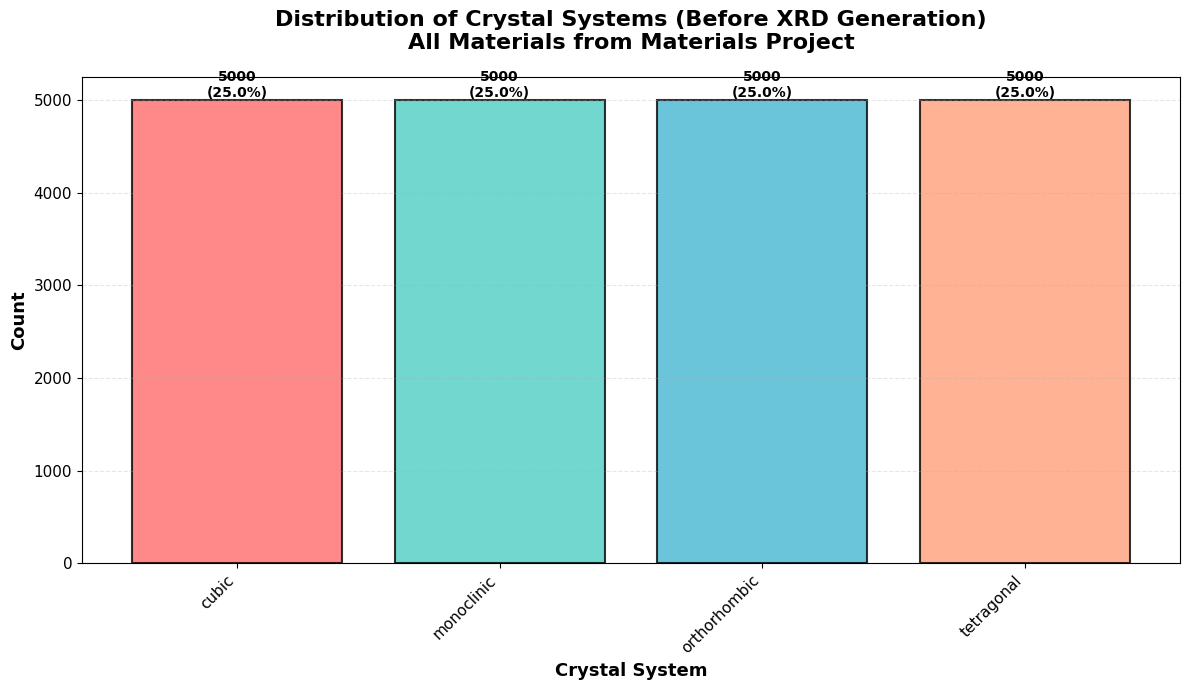

In [ ]:
# ============================================================================
# CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)
# ============================================================================

print("\n" + "="*70)
print("CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)")
print("="*70)

class_distribution = df_materials['crystal_system'].value_counts()
print("\nCount by Crystal System:")
print(class_distribution)

print("\nPercentage by Crystal System:")
class_distribution_pct = (class_distribution / len(df_materials) * 100).round(2)
for system, pct in class_distribution_pct.items():
    print(f"  {system.capitalize():<15}: {pct:>6.2f}%")

# Plot distribution
plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(class_distribution.index, class_distribution.values,
               color=colors[:len(class_distribution)],
               edgecolor='black', linewidth=1.5, alpha=0.8)

plt.title('Distribution of Crystal Systems (Before XRD Generation)\nAll Materials from Materials Project',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Crystal System', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df_materials)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# MATERIAL COMPOSITION ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MATERIAL COMPOSITION ANALYSIS")
print("="*70)

# Sample formulas from each crystal system
print("\nSample formulas from each crystal system:")
for system in TARGET_SYSTEMS:
    system_df = df_materials[df_materials['crystal_system'] == system]
    sample_formulas = system_df['formula'].head(5).tolist()
    print(f"\n{system.upper()}:")
    for i, formula in enumerate(sample_formulas, 1):
        print(f"  {i}. {formula}")


MATERIAL COMPOSITION ANALYSIS

Sample formulas from each crystal system:

CUBIC:
  1. Ac
  2. Ac2AgIr
  3. Ac2AgPb
  4. Ac2CdGa
  5. Ac2CdGe

MONOCLINIC:
  1. Ac2Mg
  2. Ag(AuF4)2
  3. Ag(AuS)2
  4. Ag(Bi2S3)3
  5. Ag(CO)2

ORTHORHOMBIC:
  1. Ac2Mg
  2. Ag(AsSe2)3
  3. Ag(BiSe2)3
  4. Ag(BiTe2)3
  5. Ag(NO)3

TETRAGONAL:
  1. Ac2Br2O
  2. Ac2Cl2O
  3. Ac2Mg
  4. Ac2S3
  5. Ac3Ag


In [ ]:
# ============================================================================
# XRD PATTERN GENERATION
# ============================================================================

def generate_xrd_patterns(df_materials, two_theta_min=TWO_THETA_MIN,
                         two_theta_max=TWO_THETA_MAX, n_points=N_POINTS):
    """Generate XRD patterns from structures"""

    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns = []
    y_systems = []
    material_ids = []  # Store material IDs
    formulas = []  # Store formulas
    valid_indices = []
    failed_count = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS")
    print("="*70)
    print(f"2θ range: {two_theta_min}° - {two_theta_max}°")
    print(f"Number of points: {n_points}")
    print(f"Wavelength: Cu Kα")
    print()

    total = len(df_materials)

    for idx, row in df_materials.iterrows():
        try:
            structure = row['structure']
            pattern = xrd_calc.get_pattern(
                structure,
                two_theta_range=(two_theta_min, two_theta_max),
            )
            intensities = np.interp(two_theta_grid, pattern.x, pattern.y)

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            material_ids.append(row['material_id'])
            formulas.append(row['formula'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:  # Only show first 3 errors
                print(f"✗ Error for {row['material_id']}: {str(e)[:50]}...")
            continue

        if (len(X_patterns) % 500) == 0:
            print(f"✓ Processed {len(X_patterns)}/{total} patterns... ({len(X_patterns)/total*100:.1f}%)")

    X_patterns = np.array(X_patterns, dtype=np.float32)
    y_systems = np.array(y_systems)
    material_ids = np.array(material_ids)
    formulas = np.array(formulas)

    print()
    print("="*70)
    print("XRD GENERATION SUMMARY")
    print("="*70)
    print(f"✓ Successfully generated: {len(X_patterns)} patterns")
    print(f"✗ Failed: {failed_count} patterns")
    print(f"Success rate: {len(X_patterns)/(len(X_patterns)+failed_count)*100:.2f}%")
    print(f"Pattern shape: {X_patterns.shape}")
    print(f"\nCrystal system distribution:")
    for system, count in Counter(y_systems).items():
        print(f"  {system.capitalize():<15}: {count:>6} patterns")

    return two_theta_grid, X_patterns, y_systems, material_ids, formulas, valid_indices

# Generate XRD patterns
two_theta_grid, X_raw, y_str, material_ids, formulas, valid_idx = generate_xrd_patterns(df_materials)

# Update dataframe to keep only valid materials
df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)

print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS
2θ range: 10° - 110°
Number of points: 2048
Wavelength: Cu Kα

✓ Processed 500/20000 patterns... (2.5%)
✓ Processed 1000/20000 patterns... (5.0%)
✓ Processed 1500/20000 patterns... (7.5%)
✓ Processed 2000/20000 patterns... (10.0%)
✓ Processed 2500/20000 patterns... (12.5%)
✓ Processed 3000/20000 patterns... (15.0%)
✓ Processed 3500/20000 patterns... (17.5%)
✓ Processed 4000/20000 patterns... (20.0%)
✓ Processed 4500/20000 patterns... (22.5%)
✓ Processed 5000/20000 patterns... (25.0%)
✓ Processed 5500/20000 patterns... (27.5%)
✓ Processed 6000/20000 patterns... (30.0%)
✓ Processed 6500/20000 patterns... (32.5%)
✓ Processed 7000/20000 patterns... (35.0%)
✓ Processed 7500/20000 patterns... (37.5%)
✓ Processed 8000/20000 patterns... (40.0%)
✓ Processed 8500/20000 patterns... (42.5%)
✓ Processed 9000/20000 patterns... (45.0%)
✓ Processed 9500/20000 patterns... (47.5%)
✓ Processed 10000/20000 patterns... (50.0%)
✓ Processed 10500/20000 patterns... (52.5%)
✓ Processed 


XRD PATTERN VISUALIZATION (WITH FORMULA)
Displaying 1 sample per crystal system (sorted by 2θ)
Plotting Cubic: 10000 samples available
Plotting Monoclinic: 10000 samples available
Plotting Orthorhombic: 10000 samples available
Plotting Tetragonal: 10000 samples available


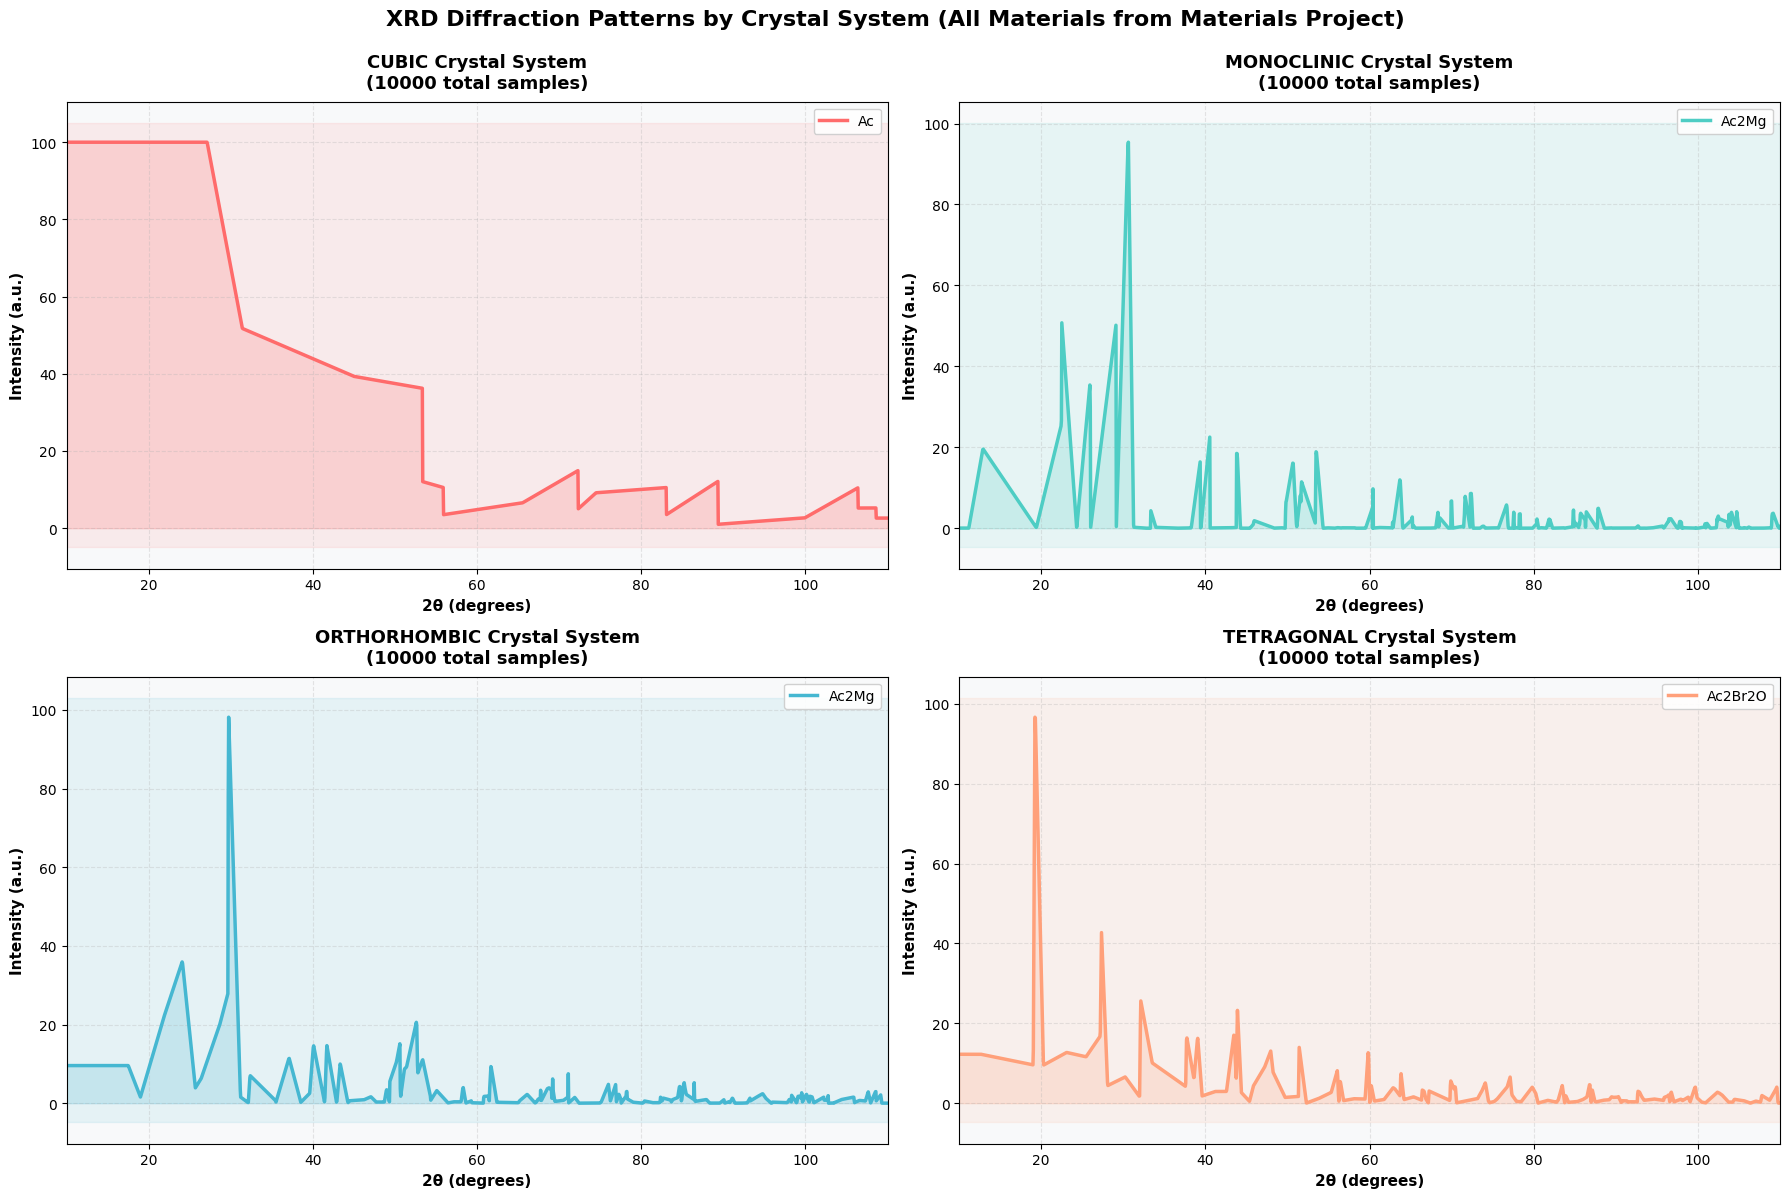


✓ XRD patterns visualization complete!
✓ Each pattern shows chemical formula


In [ ]:
# ============================================================================
# XRD PATTERN VISUALIZATION (WITH FORMULA ONLY)
# ============================================================================

print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION (WITH FORMULA)")
print("="*70)
print("Displaying 1 sample per crystal system (sorted by 2θ)")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

colors_map = {
    'cubic': '#FF6B6B',
    'monoclinic': '#4ECDC4',
    'orthorhombic': '#45B7D1',
    'tetragonal': '#FFA07A'
}

for idx, system in enumerate(TARGET_SYSTEMS):
    ax = axes[idx]

    # Get indices for this system
    system_indices = np.where(y_str == system)[0]

    print(f"Plotting {system.capitalize()}: {len(system_indices)} samples available")

    if len(system_indices) > 0:
        # Take only 1 sample (first sample)
        sample_idx = system_indices[0]

        # Get formula
        formula = formulas[sample_idx]

        # Get pattern data
        pattern_data = X_raw[sample_idx]

        # Sort by 2θ (should already be sorted, but ensuring)
        sorted_indices = np.argsort(two_theta_grid)
        two_theta_sorted = two_theta_grid[sorted_indices]
        pattern_sorted = pattern_data[sorted_indices]

        # Plot the sorted pattern
        ax.plot(two_theta_sorted, pattern_sorted,
               linewidth=2.5,
               color=colors_map[system],
               label=f'{formula}')

        # Fill under the curve for better visualization
        ax.fill_between(two_theta_sorted, pattern_sorted,
                        alpha=0.2, color=colors_map[system])

    ax.set_title(f'{system.upper()} Crystal System\n({len(system_indices)} total samples)',
                fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('2θ (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')

    # Add subtle background color
    ax.axhspan(ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color=colors_map[system])

    # Set x-axis limits
    ax.set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)

plt.suptitle('XRD Diffraction Patterns by Crystal System (All Materials from Materials Project)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ XRD patterns visualization complete!")
print("✓ Each pattern shows chemical formula")

In [ ]:
# ============================================================================
# DATA PREPARATION: ENCODING & SPLITTING (70:10:20)
# ============================================================================

print("\n" + "="*70)
print("DATA PREPARATION: ENCODING & SPLITTING")
print("="*70)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_str)
class_names = list(le.classes_)

print("\nClass Encoding Mapping:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} → {name.capitalize():<15} ({count} samples)")

# Split data: 70% train, 10% validation, 20% test
# First split: 80% (train+val), 20% test
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

# Second split: 70% train, 10% validation (from the 80%)
# 10/80 = 0.125
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp
)

print("\n" + "-"*70)
print("DATA SPLIT (70% Train / 10% Validation / 20% Test)")
print("-"*70)
print(f"Training set size:     {len(X_train_raw):>6} samples ({len(X_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Validation set size:   {len(X_val_raw):>6} samples ({len(X_val_raw)/len(X_raw)*100:.1f}%)")
print(f"Test set size:         {len(X_test_raw):>6} samples ({len(X_test_raw)/len(X_raw)*100:.1f}%)")
print(f"Total:                 {len(X_raw):>6} samples")

print("\nTraining Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_train)*100:>5.1f}%)")

print("\nValidation Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_val)*100:>5.1f}%)")

print("\nTest Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_test)*100:>5.1f}%)")


DATA PREPARATION: ENCODING & SPLITTING

Class Encoding Mapping:
  0 → Cubic           (10000 samples)
  1 → Monoclinic      (10000 samples)
  2 → Orthorhombic    (10000 samples)
  3 → Tetragonal      (10000 samples)

----------------------------------------------------------------------
DATA SPLIT (70% Train / 10% Validation / 20% Test)
----------------------------------------------------------------------
Training set size:      28000 samples (70.0%)
Validation set size:     4000 samples (10.0%)
Test set size:           8000 samples (20.0%)
Total:                  40000 samples

Training Set Distribution:
  Cubic          :  7000 samples ( 25.0%)
  Monoclinic     :  7000 samples ( 25.0%)
  Orthorhombic   :  7000 samples ( 25.0%)
  Tetragonal     :  7000 samples ( 25.0%)

Validation Set Distribution:
  Cubic          :  1000 samples ( 25.0%)
  Monoclinic     :  1000 samples ( 25.0%)
  Orthorhombic   :  1000 samples ( 25.0%)
  Tetragonal     :  1000 samples ( 25.0%)

Test Set Distribut

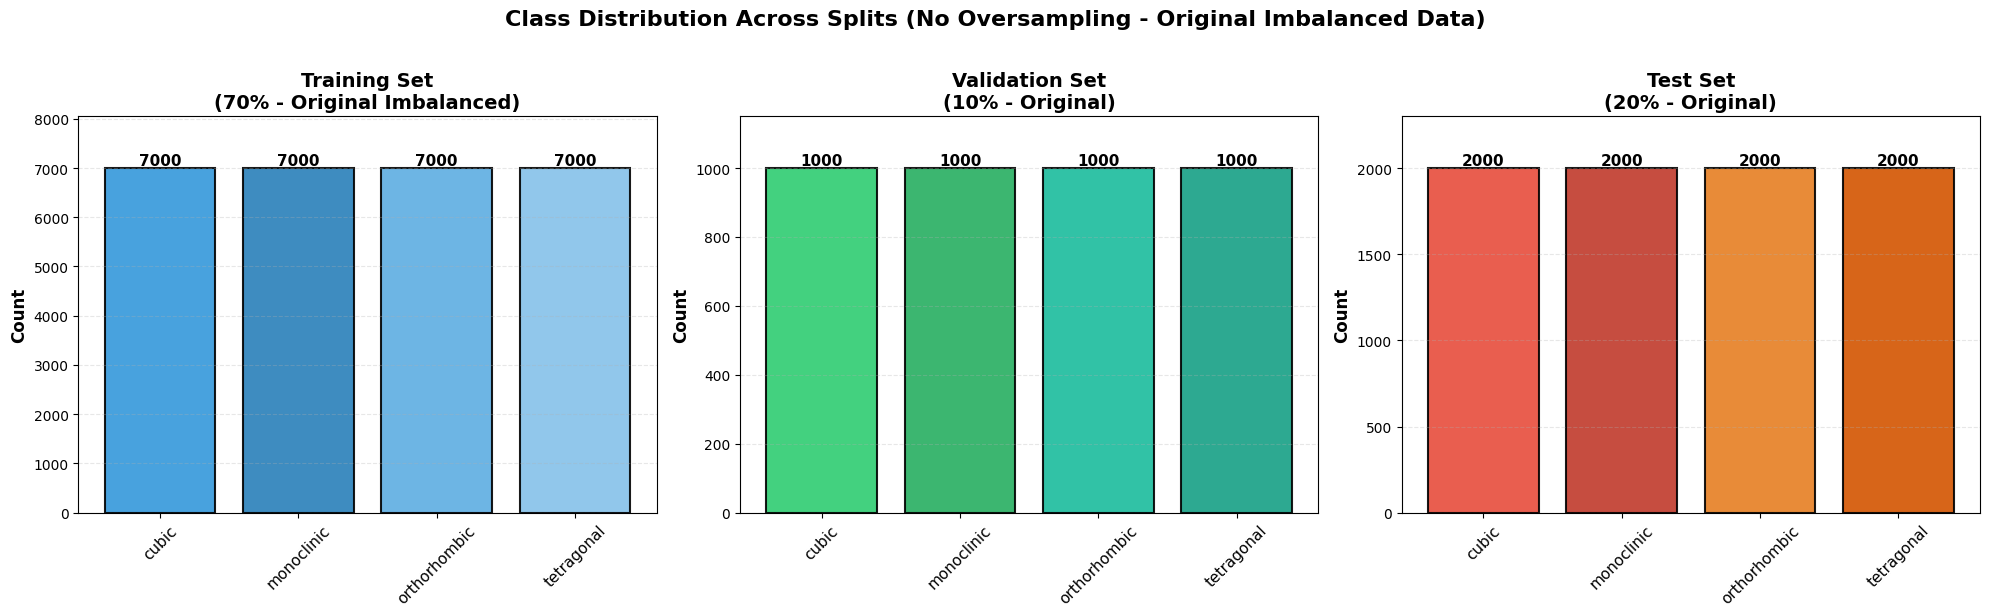

In [ ]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors_train = ['#3498db', '#2980b9', '#5dade2', '#85c1e9']
colors_val = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
colors_test = ['#e74c3c', '#c0392b', '#e67e22', '#d35400']

# Plot 1: Training Set
unique, counts = np.unique(y_train, return_counts=True)
labels = [class_names[i] for i in unique]
bars1 = axes[0].bar(labels, counts, color=colors_train, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[0].set_title('Training Set\n(70% - Original Imbalanced)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Validation Set
unique, counts = np.unique(y_val, return_counts=True)
labels = [class_names[i] for i in unique]
bars2 = axes[1].bar(labels, counts, color=colors_val, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[1].set_title('Validation Set\n(10% - Original)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars2, counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Test Set
unique, counts = np.unique(y_test, return_counts=True)
labels = [class_names[i] for i in unique]
bars3 = axes[2].bar(labels, counts, color=colors_test, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[2].set_title('Test Set\n(20% - Original)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=11)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars3, counts):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Class Distribution Across Splits (No Oversampling - Original Imbalanced Data)',
            fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*70)
print("SAMPLE COUNTS SUMMARY TABLE (NO OVERSAMPLING)")
print("="*70)

summary_data = []
total_train = 0
total_val = 0
total_test = 0

for i, system in enumerate(class_names):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)

    total_train += train_count
    total_val += val_count
    total_test += test_count

    summary_data.append({
        'Crystal System': system.capitalize(),
        'Training': train_count,
        'Validation': val_count,
        'Test': test_count,
        'Total': train_count + val_count + test_count
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "-"*70)
print(f"{'TOTAL':<20} {total_train:>10} {total_val:>12} {total_test:>6} {total_train+total_val+total_test:>7}")
print("="*70)

print(f"\n✓ Data split complete (70:10:20)")
print(f"✓ NO oversampling applied - using original imbalanced data")


SAMPLE COUNTS SUMMARY TABLE (NO OVERSAMPLING)
Crystal System  Training  Validation  Test  Total
         Cubic      7000        1000  2000  10000
    Monoclinic      7000        1000  2000  10000
  Orthorhombic      7000        1000  2000  10000
    Tetragonal      7000        1000  2000  10000

----------------------------------------------------------------------
TOTAL                     28000         4000   8000   40000

✓ Data split complete (70:10:20)
✓ NO oversampling applied - using original imbalanced data


In [ ]:
# ============================================================================
# MODEL ARCHITECTURE DEFINITIONS
# ============================================================================

def build_cnn_fixed(input_shape, num_classes: int):
    """
    Build CNN with fixed architecture
    """
    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1
    x = layers.Conv1D(filters=80, kernel_size=100, strides=5,
                      activation="relu", padding="same", name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2
    x = layers.Conv1D(filters=80, kernel_size=80, strides=5,
                      activation="relu", padding="same", name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3
    x = layers.Conv1D(filters=80, kernel_size=20, strides=5,
                      activation="relu", padding="same", name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer)
    x = layers.Dense(64, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_Fixed")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def build_cnn_woa(params, input_shape, num_classes):
    """
    Build CNN with WOA-optimized hyperparameters
    """
    num_filters = int(params[0])
    fc1_units = int(params[1])
    fc2_units = int(params[2])

    inputs = layers.Input(shape=input_shape)

    # Convolutional layers
    x = layers.Conv1D(filters=num_filters, kernel_size=100, strides=5,
                      activation="relu", padding="same", name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    x = layers.Conv1D(filters=num_filters, kernel_size=80, strides=5,
                      activation="relu", padding="same", name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    x = layers.Conv1D(filters=num_filters, kernel_size=20, strides=5,
                      activation="relu", padding="same", name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected layers
    x = layers.Dense(fc1_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    x = layers.Dense(fc2_units, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_WOA")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [ ]:
# ============================================================================
# PREPARE DATA FOR TRAINING
# ============================================================================

# Reshape data for CNN (add channel dimension)
X_train = X_train_raw[..., np.newaxis]
X_val = X_val_raw[..., np.newaxis]
X_test = X_test_raw[..., np.newaxis]

print("\n" + "="*70)
print("DATA SHAPES FOR TRAINING")
print("="*70)
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print("\n✓ All data ready for training!")


DATA SHAPES FOR TRAINING
X_train: (28000, 2048, 1)
X_val:   (4000, 2048, 1)
X_test:  (8000, 2048, 1)

✓ All data ready for training!


In [ ]:
# ============================================================================
# TRAIN MODEL 1: CNN FIXED
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 1: CNN (FIXED ARCHITECTURE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=100, stride=5")
print("  - Conv2: 80 filters, kernel=80,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Training Data: Original Imbalanced Data (NO Oversampling)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn = build_cnn_fixed(X_train.shape[1:], num_classes=len(class_names))
model_cnn.summary()

# Train model
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN Model training complete!")


TRAINING MODEL 1: CNN (FIXED ARCHITECTURE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=100, stride=5
  - Conv2: 80 filters, kernel=80,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Training Data: Original Imbalanced Data (NO Oversampling)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       512,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,364 (2.58 MB)

 Trainable params: 677,364 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.5259 - loss: 1.0452 - val_accuracy: 0.6010 - val_loss: 0.8499
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6380 - loss: 0.8157 - val_accuracy: 0.6850 - val_loss: 0.7295
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6820 - loss: 0.7301 - val_accuracy: 0.7105 - val_loss: 0.6850
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7025 - loss: 0.6827 - val_accuracy: 0.7057 - val_loss: 0.6831
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7274 - loss: 0.6371 - val_accuracy: 0.7240 - val_loss: 0.6602
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7561 - loss: 0.5865 - val_accuracy: 0.7153 - val_loss: 0.6758
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7677 - loss: 0.5410 - val_accuracy: 0.7212 - val_loss: 0.6889
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7853 - loss: 0.5145 -

In [ ]:
# ============================================================================
# WHALE OPTIMIZATION ALGORITHM
# ============================================================================

class WhaleOptimization:
    def __init__(self, n_whales, n_iterations, bounds):
        self.n_whales = n_whales
        self.n_iterations = n_iterations
        self.bounds = bounds
        self.dim = len(bounds)

    def initialize_population(self):
        population = np.zeros((self.n_whales, self.dim))
        for i in range(self.dim):
            population[:, i] = np.random.uniform(
                self.bounds[i][0],
                self.bounds[i][1],
                self.n_whales
            )
        return population

    def optimize(self, fitness_function):
        population = self.initialize_population()
        fitness = np.array([fitness_function(ind) for ind in population])

        best_idx = np.argmax(fitness)
        best_position = population[best_idx].copy()
        best_fitness = fitness[best_idx]

        fitness_history = [best_fitness]

        print(f"Initial best fitness: {best_fitness:.4f}")

        for iteration in range(self.n_iterations):
            a = 2 - iteration * (2 / self.n_iterations)

            for i in range(self.n_whales):
                r1 = np.random.random()
                r2 = np.random.random()

                A = 2 * a * r1 - a
                C = 2 * r2

                p = np.random.random()

                if p < 0.5:
                    if abs(A) < 1:
                        D = abs(C * best_position - population[i])
                        population[i] = best_position - A * D
                    else:
                        rand_idx = np.random.randint(0, self.n_whales)
                        rand_whale = population[rand_idx]
                        D = abs(C * rand_whale - population[i])
                        population[i] = rand_whale - A * D
                else:
                    D_prime = abs(best_position - population[i])
                    l = np.random.uniform(-1, 1)
                    population[i] = D_prime * np.exp(l) * np.cos(2 * np.pi * l) + best_position

                for j in range(self.dim):
                    population[i, j] = np.clip(
                        population[i, j],
                        self.bounds[j][0],
                        self.bounds[j][1]
                    )

            fitness = np.array([fitness_function(ind) for ind in population])

            current_best_idx = np.argmax(fitness)
            if fitness[current_best_idx] > best_fitness:
                best_fitness = fitness[current_best_idx]
                best_position = population[current_best_idx].copy()

            fitness_history.append(best_fitness)

            if (iteration + 1) % 2 == 0:
                print(f"Iteration {iteration + 1}/{self.n_iterations} - Best fitness: {best_fitness:.4f}")

        return best_position, best_fitness, fitness_history

print("✓ WOA class defined successfully!")

✓ WOA class defined successfully!


In [ ]:
# ============================================================================
# WOA OPTIMIZATION FOR CNN
# ============================================================================

def fitness_function(params):
    """Fitness function for WOA (validation accuracy)"""
    try:
        model = build_cnn_woa(params, X_train.shape[1:], len(class_names))

        history = model.fit(
            X_train, y_train,
            epochs=5,
            batch_size=BATCH_SIZE,
            validation_data=(X_val, y_val),
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])

        tf.keras.backend.clear_session()

        return val_acc
    except Exception as e:
        print(f"Error in fitness function: {e}")
        return 0.0

# WOA hyperparameter bounds
bounds = [
    (64, 128),   # num_filters
    (64, 256),   # fc1_units
    (32, 128),   # fc2_units
]

print("\n" + "="*70)
print("OPTIMIZING CNN WITH WOA")
print("="*70)
print("WOA will optimize:")
print("  1. Number of filters (same for all 3 Conv layers)")
print("  2. Fully Connected Layer 1 units")
print("  3. Fully Connected Layer 2 units (feature layer)")
print()
print(f"Number of whales: 8")
print(f"Number of iterations: 10")
print(f"Hyperparameter bounds:")
print(f"  - Conv filters: {bounds[0]}")
print(f"  - FC1 units:    {bounds[1]}")
print(f"  - FC2 units:    {bounds[2]}")
print()

woa = WhaleOptimization(n_whales=8, n_iterations=10, bounds=bounds)
best_params, best_fitness, fitness_hist = woa.optimize(fitness_function)

print(f"\n{'='*70}")
print(f"WOA OPTIMIZATION COMPLETE!")
print(f"{'='*70}")
print(f"Best parameters: {best_params}")
print(f"  - Conv filters (all layers): {int(best_params[0])}")
print(f"  - FC1 units: {int(best_params[1])}")
print(f"  - FC2 units (feature layer): {int(best_params[2])}")
print(f"Best validation accuracy: {best_fitness:.4f}")


OPTIMIZING CNN WITH WOA
WOA will optimize:
  1. Number of filters (same for all 3 Conv layers)
  2. Fully Connected Layer 1 units
  3. Fully Connected Layer 2 units (feature layer)

Number of whales: 8
Number of iterations: 10
Hyperparameter bounds:
  - Conv filters: (64, 128)
  - FC1 units:    (64, 256)
  - FC2 units:    (32, 128)

Initial best fitness: 0.7237
Iteration 2/10 - Best fitness: 0.7258
Iteration 4/10 - Best fitness: 0.7258
Iteration 6/10 - Best fitness: 0.7333
Iteration 8/10 - Best fitness: 0.7333
Iteration 10/10 - Best fitness: 0.7333

WOA OPTIMIZATION COMPLETE!
Best parameters: [128. 256. 128.]
  - Conv filters (all layers): 128
  - FC1 units: 256
  - FC2 units (feature layer): 128
Best validation accuracy: 0.7333


In [ ]:
# ============================================================================
# TRAIN MODEL 2: CNN+WOA
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 2: CNN+WOA (OPTIMIZED ARCHITECTURE)")
print("="*70)

print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print(f"• Conv filters (all 3 layers): {int(best_params[0])}")
print(f"• FC1 units: {int(best_params[1])}")
print(f"• FC2 units: {int(best_params[2])}")
print("• Training Data: Original Imbalanced Data (NO Oversampling)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_woa = build_cnn_woa(best_params, X_train.shape[1:], len(class_names))
model_cnn_woa.summary()

# Train model
history_cnn_woa = model_cnn_woa.fit(
    X_train, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n✓ CNN+WOA Model training complete!")


TRAINING MODEL 2: CNN+WOA (OPTIMIZED ARCHITECTURE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• Conv filters (all 3 layers): 128
• FC1 units: 256
• FC2 units: 128
• Training Data: Original Imbalanced Data (NO Oversampling)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 128)       │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 128)        │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 128)         │       327,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,750,788 (6.68 MB)

 Trainable params: 1,750,788 (6.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5530 - loss: 1.0091 - val_accuracy: 0.6332 - val_loss: 0.7737
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6447 - loss: 0.7891 - val_accuracy: 0.6793 - val_loss: 0.7164
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6843 - loss: 0.7192 - val_accuracy: 0.6842 - val_loss: 0.7656
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6926 - loss: 0.7072 - val_accuracy: 0.6920 - val_loss: 0.7072
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7234 - loss: 0.6299 - val_accuracy: 0.7153 - val_loss: 0.6844
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7541 - loss: 0.5768 - val_accuracy: 0.7175 - val_loss: 0.7116
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7756 - loss: 0.5301 - val_accuracy: 0.7138 - val_loss: 0.7430
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7946 - loss: 0.4903 -

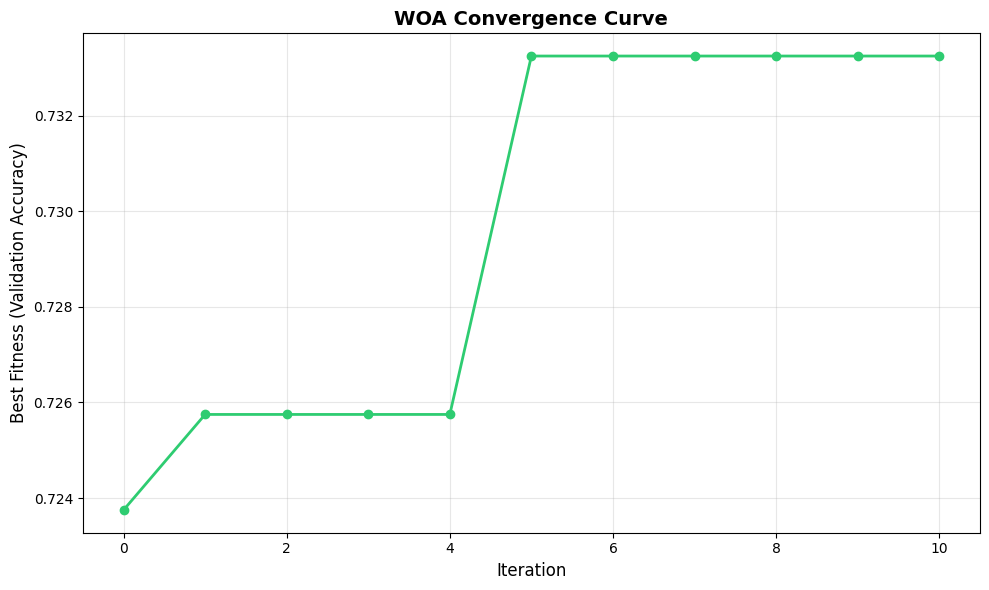

In [ ]:
# ============================================================================
# PLOT WOA CONVERGENCE CURVE
# ============================================================================

plt.figure(figsize=(10, 6))
plt.plot(range(len(fitness_hist)), fitness_hist,
         marker='o', linewidth=2, markersize=6, color='#2ecc71')
plt.title('WOA Convergence Curve', fontweight='bold', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Fitness (Validation Accuracy)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================

# Predictions
y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)
y_pred_cnn_woa = np.argmax(model_cnn_woa.predict(X_test, verbose=0), axis=1)

# Calculate metrics
models_results = {}

for model_name, y_pred in [
    ("CNN (Fixed)", y_pred_cnn),
    ("CNN+WOA (Optimized)", y_pred_cnn_woa)
]:
    models_results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average="macro", zero_division=0),
        'recall': recall_score(y_test, y_pred, average="macro", zero_division=0),
        'f1': f1_score(y_test, y_pred, average="macro", zero_division=0),
        'predictions': y_pred
    }

# Display results
print("\n" + "="*70)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*70)

comparison_df = pd.DataFrame(models_results).T
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Predictions']
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

print(comparison_df.to_string())

# Highlight best performers
print("\n" + "-"*70)
print("BEST PERFORMERS:")
print("-"*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:<12}: {best_model:<25} ({best_value:.4f})")


MODEL COMPARISON - TEST SET PERFORMANCE
                     Accuracy Precision    Recall  F1-Score
CNN (Fixed)          0.714375  0.709556  0.714375  0.710672
CNN+WOA (Optimized)  0.710375  0.703005  0.710375  0.705094

----------------------------------------------------------------------
BEST PERFORMERS:
----------------------------------------------------------------------
Accuracy    : CNN (Fixed)               (0.7144)
Precision   : CNN (Fixed)               (0.7096)
Recall      : CNN (Fixed)               (0.7144)
F1-Score    : CNN (Fixed)               (0.7107)


In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, results in models_results.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    print(classification_report(y_test, results['predictions'], target_names=class_names))


DETAILED CLASSIFICATION REPORTS

CNN (Fixed):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.91      0.93      0.92      2000
  monoclinic       0.67      0.69      0.68      2000
orthorhombic       0.57      0.49      0.52      2000
  tetragonal       0.68      0.76      0.72      2000

    accuracy                           0.71      8000
   macro avg       0.71      0.71      0.71      8000
weighted avg       0.71      0.71      0.71      8000


CNN+WOA (Optimized):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.88      0.94      0.91      2000
  monoclinic       0.65      0.71      0.68      2000
orthorhombic       0.57      0.48      0.52      2000
  tetragonal       0.71      0.71      0.71      2000

    accuracy                           0.71      8000
   macro avg       0.70     

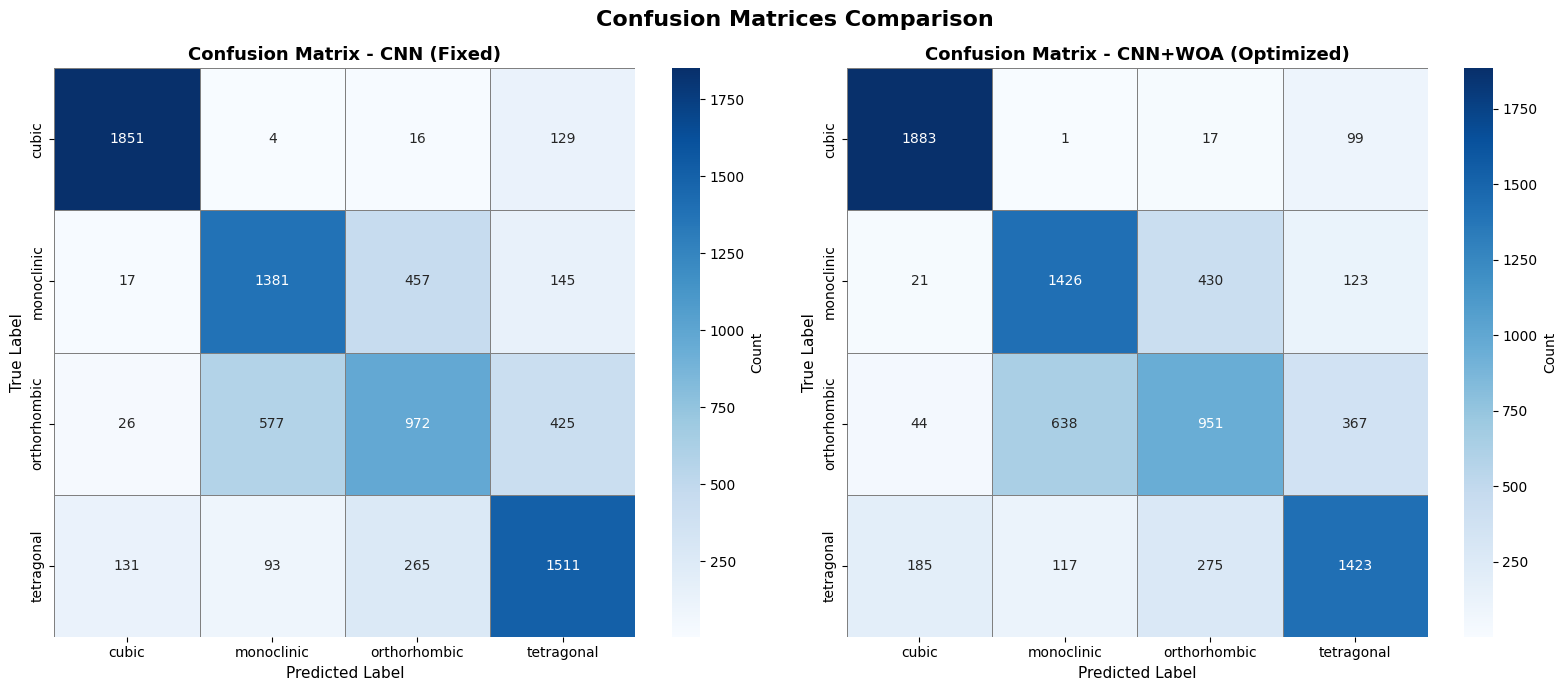

In [ ]:
# ============================================================================
# CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray',
                ax=axes[idx])

    axes[idx].set_title(f'Confusion Matrix - {model_name}', fontweight='bold', fontsize=13)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices Comparison', fontweight='bold', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


PER-CLASS ACCURACY COMPARISON
              CNN (Fixed)  CNN+WOA (Optimized)
cubic              0.9255               0.9415
monoclinic         0.6905               0.7130
orthorhombic       0.4860               0.4755
tetragonal         0.7555               0.7115


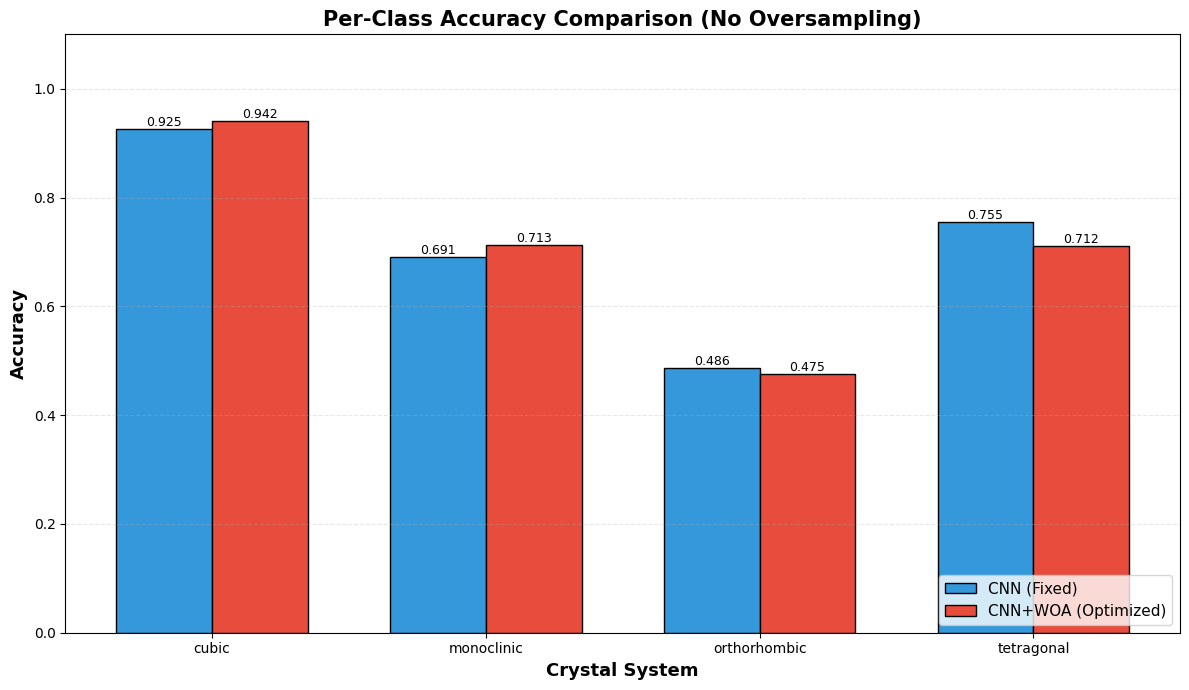

In [ ]:
# ============================================================================
# PER-CLASS ACCURACY COMPARISON
# ============================================================================

print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON")
print("="*70)

per_class_results = {}

for model_name, results in models_results.items():
    cm = confusion_matrix(y_test, results['predictions'])
    per_class_acc = []

    for i in range(len(class_names)):
        if cm[i].sum() > 0:
            per_class_acc.append(cm[i, i] / cm[i].sum())
        else:
            per_class_acc.append(0.0)

    per_class_results[model_name] = per_class_acc

# Create DataFrame
per_class_df = pd.DataFrame(per_class_results, index=class_names)
print(per_class_df.to_string())

# Visualize per-class accuracy
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(class_names))
width = 0.35

colors = ['#3498db', '#e74c3c']

for idx, (model_name, color) in enumerate(zip(per_class_results.keys(), colors)):
    offset = width * (idx - 0.5)
    bars = ax.bar(x + offset, per_class_results[model_name], width,
                  label=model_name, color=color, edgecolor='black', linewidth=1)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Crystal System', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Per-Class Accuracy Comparison (No Oversampling)', fontweight='bold', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# FEATURE EXTRACTION AND t-SNE VISUALIZATION
# ============================================================================

def extract_cnn_features(model, X_data):
    """Extract features from feature layer"""
    if len(X_data.shape) == 2:
        X_data = X_data[..., np.newaxis]
    feature_layer = model.get_layer("feature_layer")
    feat_model = Model(inputs=model.input, outputs=feature_layer.output)
    return feat_model.predict(X_data, verbose=0, batch_size=32)

print("\n" + "="*70)
print("EXTRACTING FEATURES FOR t-SNE VISUALIZATION")
print("="*70)

# Extract features
features_cnn = extract_cnn_features(model_cnn, X_test_raw)
features_cnn_woa = extract_cnn_features(model_cnn_woa, X_test_raw)

print("✓ Feature extraction complete!")


EXTRACTING FEATURES FOR t-SNE VISUALIZATION
✓ Feature extraction complete!


In [ ]:
# ============================================================================
# t-SNE VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("GENERATING t-SNE VISUALIZATIONS")
print("="*70)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000, verbose=0)

print("Applying t-SNE to CNN features...")
X_tsne_cnn = tsne.fit_transform(features_cnn)

print("Applying t-SNE to CNN+WOA features...")
X_tsne_cnn_woa = tsne.fit_transform(features_cnn_woa)

print("✓ t-SNE transformation complete!")


GENERATING t-SNE VISUALIZATIONS
Applying t-SNE to CNN features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Applying t-SNE to CNN+WOA features...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ t-SNE transformation complete!


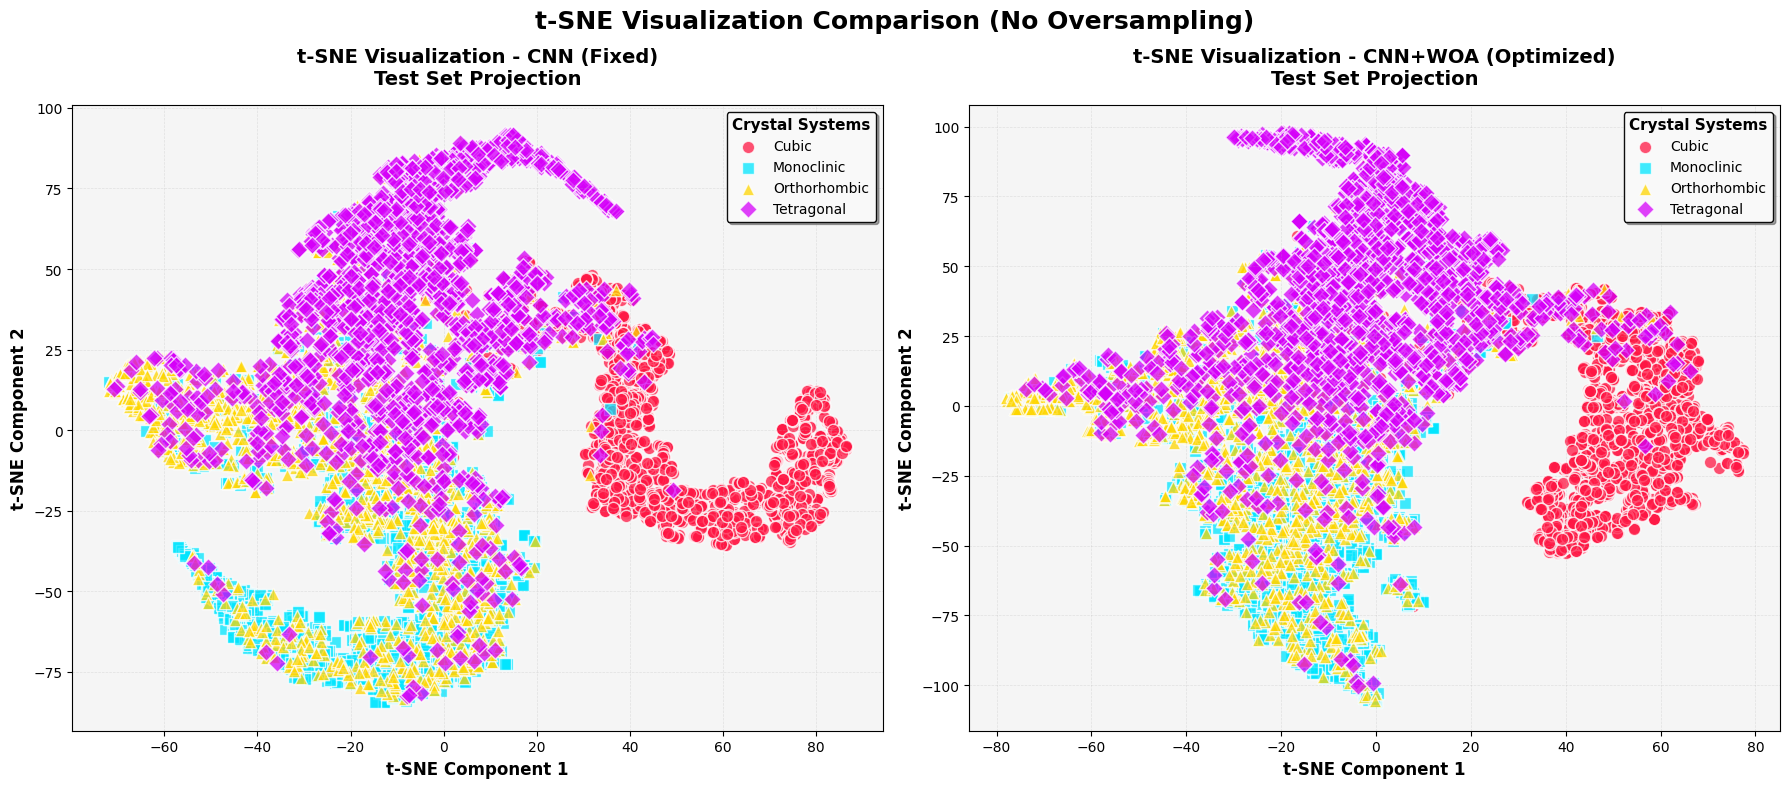


✓ t-SNE visualizations complete!


In [ ]:
# ============================================================================
# PLOT t-SNE VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colors_bright = ['#FF1744', '#00E5FF', '#FFD600', '#D500F9']
markers = ['o', 's', '^', 'D']

tsne_data = [
    (X_tsne_cnn, "CNN (Fixed)"),
    (X_tsne_cnn_woa, "CNN+WOA (Optimized)")
]

for idx, (X_tsne, title) in enumerate(tsne_data):
    ax = axes[idx]

    for i, name in enumerate(class_names):
        mask = (y_test == i)
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colors_bright[i],
                   label=name.capitalize(),
                   s=80,
                   alpha=0.75,
                   edgecolors='white',
                   linewidths=1.0,
                   marker=markers[i])

    ax.set_title(f't-SNE Visualization - {title}\nTest Set Projection',
                 fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')

    legend = ax.legend(fontsize=10, loc='best', framealpha=0.95,
                       edgecolor='black', fancybox=True, shadow=True)
    legend.set_title('Crystal Systems', prop={'size': 11, 'weight': 'bold'})

    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_facecolor('#F5F5F5')

plt.suptitle('t-SNE Visualization Comparison (No Oversampling)',
            fontweight='bold', fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

print("\n✓ t-SNE visualizations complete!")

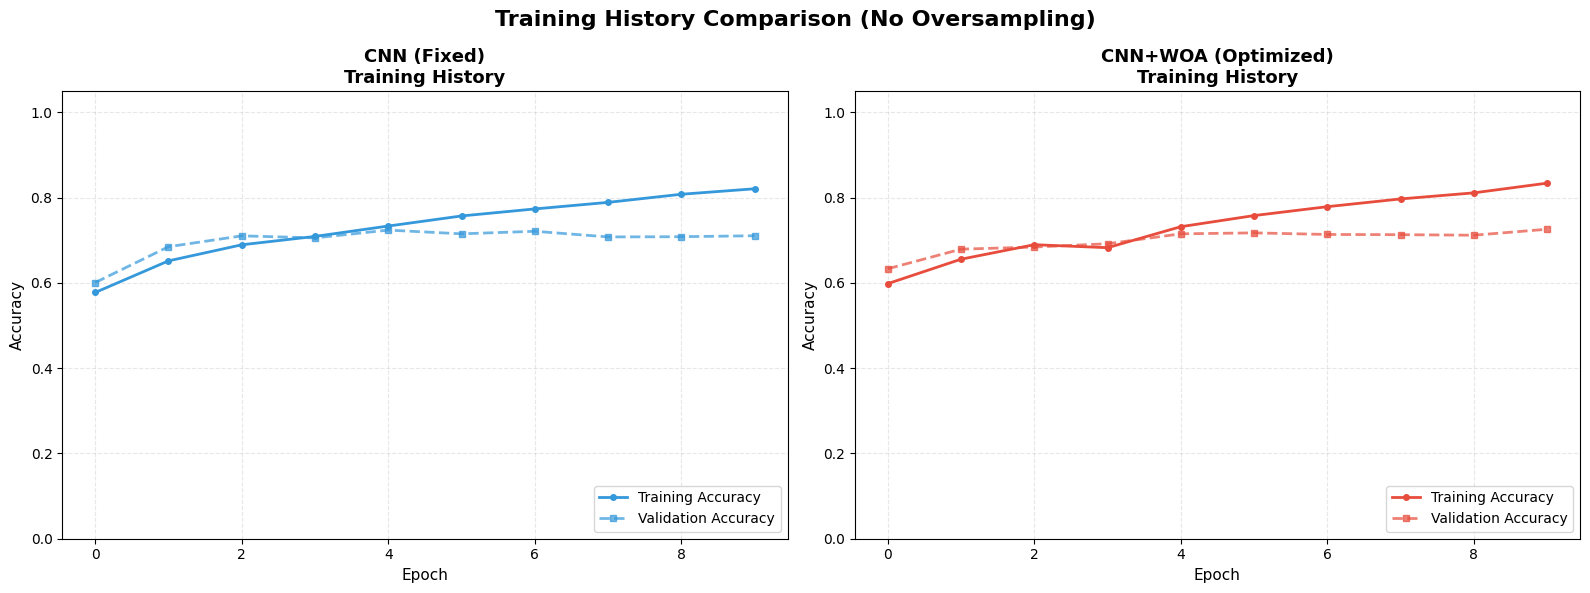

In [ ]:
# ============================================================================
# TRAINING HISTORY COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

histories = [
    (history_cnn, "CNN (Fixed)", '#3498db'),
    (history_cnn_woa, "CNN+WOA (Optimized)", '#e74c3c')
]

for idx, (history, title, color) in enumerate(histories):
    ax = axes[idx]

    # Plot training and validation accuracy
    ax.plot(history.history['accuracy'], label='Training Accuracy',
            linewidth=2, color=color, linestyle='-', marker='o', markersize=4)
    ax.plot(history.history['val_accuracy'], label='Validation Accuracy',
            linewidth=2, color=color, linestyle='--', marker='s', markersize=4, alpha=0.7)

    ax.set_title(f'{title}\nTraining History', fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.05)

plt.suptitle('Training History Comparison (No Oversampling)',
            fontweight='bold', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()